In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
import re

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch # For legend

from scipy.stats import spearmanr
from scipy.spatial.distance import squareform

In [3]:
#column name
def rename_sample_columns(input_file='merged_tpm_data.csv'):
    # 1. 데이터 불러오기
    df = pd.read_csv(input_file)

    # 2. 컬럼명 분리
    columns = df.columns.tolist()
    gene_col = columns[0]  # GeneID 컬럼
    sample_cols = columns[1:]  # 샘플 컬럼들

    # 3. 코드 매핑 생성 (stage-tissue-code -> stage-tissue-숫자)
    code_mapping = {}
    code_counter = {}
    new_columns = [gene_col]

    for col in sample_cols:
        # 마지막 하이픈 뒤의 코드 추출
        parts = col.rsplit('-', 1)
        if len(parts) == 2:
            prefix = parts[0]  # stage-tissue 부분
            original_code = parts[1]  # 원래 코드
            
            # 해당 stage-tissue에 대한 카운터 생성
            if prefix not in code_counter:
                code_counter[prefix] = 1
            
            new_code = code_counter[prefix]
            new_col_name = f"{prefix}-{new_code}"
            
            # 매핑 저장
            code_mapping[new_col_name] = original_code
            
            new_columns.append(new_col_name)
            code_counter[prefix] += 1
        else:
            new_columns.append(col)

    # 4. 컬럼명 변경
    df.columns = new_columns
    df_filtered = df[~df['GeneID'].str.contains('STRG', na=False)]

    print(f"Original data shape: {df.shape}")
    print(f"Filtered data shape: {df_filtered.shape}")
    print(f"Removed {df.shape[0] - df_filtered.shape[0]} rows containing 'STRG'")

    # 5. 코드 매핑을 txt 파일로 저장
    with open('code_mapping.txt', 'w') as f:
        f.write("New_Code\tOriginal_Code\n")
        for new_code, original_code in sorted(code_mapping.items()):
            f.write(f"{new_code}\t{original_code}\n")

    print("코드 매핑이 'code_mapping.txt'에 저장되었습니다.")
    print(f"\n변경된 컬럼명 예시:")
    print(df.columns[:10].tolist())

    return df_filtered

In [4]:
def violin_plot(df, title = 'Distribution of Gene Expression', ylabel='log2(TPM + 1)', filename='violin_plot_samples.png'):
    df_long = df.melt(var_name='Sample', value_name='Expression')

# Create violin plot
    plt.figure(figsize=(16, 8))
    sns.violinplot(data=df_long, x='Sample', y= 'Expression', 
                palette='Set2', inner='box', linewidth=1.5)

    plt.xticks(rotation=90, ha='right')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Sample', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [5]:

def filter_genes_low(df_filtered):
    df_filtered = df_filtered.set_index('GeneID')
    df_filtered = df_filtered.replace([np.inf, -np.inf], np.nan)
    df_filtered = df_filtered.fillna(0)
    df_filtered = df_filtered[(df_filtered > 1).any(axis=1)]
   
    return df_filtered

def filter_genes_var(df_filtered, var_threshold=0.01):
    df_filtered = df_filtered.set_index('GeneID')
    df_filtered = df_filtered.replace([np.inf, -np.inf], np.nan)
    df_filtered = df_filtered.fillna(0)
    gene_vars = df_filtered.var(axis=1)
    df_filtered = df_filtered[(df_filtered > 1).any(axis=1)]
    df_filtered = df_filtered[gene_vars > var_threshold]
    return df_filtered

In [6]:
# Remove rows where Gene ID contains 'STRG'
def filter_genes_by_replicate(df_expr):
    """
    Replicate 그룹별로 gene 필터링
    
    Parameters:
    -----------
    df_expr : pandas.DataFrame
        GeneID가 인덱스로 설정된 expression 데이터프레임
    
    Returns:
    --------
    pandas.DataFrame
        필터링된 데이터프레임 (인덱스가 GeneID)
    """
    
    # log2(TPM+1) 변환
    
    df_log = np.log2(df_expr + 1)
    # replicate 그룹 정의 (stage-tissue가 같은 샘플들)
    replicate_groups = {}
    for col in df_log.columns:
        # stage-tissue 추출 (마지막 하이픈 앞까지)
        stage_tissue = col.rsplit('-', 1)[0]
        if stage_tissue not in replicate_groups:
            replicate_groups[stage_tissue] = []
        replicate_groups[stage_tissue].append(col)
    
    print(f"\n발견된 replicate 그룹 수: {len(replicate_groups)}")
    for group, samples in list(replicate_groups.items())[:5]:
        print(f"  {group}: {len(samples)} replicates")
    
    # 각 replicate 그룹별로 필터링 조건 확인
    genes_to_remove = set()
    
    for stage_tissue, sample_list in replicate_groups.items():
        # 해당 그룹의 샘플들만 선택
        group_data = df_log[sample_list]
        
        # 각 gene에 대해
        for gene in group_data.index:
            values = group_data.loc[gene].values
            
            # median과 max 계산
            median_val = np.median(values)
            max_val = np.max(values)
            
            # 조건: max - median ≥ 2 이고 median ≤ 1
            if (max_val - median_val >= 2) and (median_val <= 1):
                genes_to_remove.add(gene)
    
    print(f"\n제거할 gene 수: {len(genes_to_remove)}")
    print(f"전체 gene 수: {len(df_expr)}")
    print(f"남을 gene 수: {len(df_expr) - len(genes_to_remove)}")
    
    # 필터링된 데이터 생성
    df_filtered = df_expr[~df_expr.index.isin(genes_to_remove)]
    
    # 제거된 gene 목록 저장
    removed_genes_df = pd.DataFrame({
        'GeneID': list(genes_to_remove)
    })
    removed_genes_df.to_csv('removed_genes.txt', index=False)
    print("\n제거된 gene 목록이 'removed_genes.txt'에 저장되었습니다.")
    
    # 필터링 통계 출력
    print("\n=== 필터링 통계 ===")
    for stage_tissue, sample_list in sorted(replicate_groups.items())[:10]:
        group_data = df_log[sample_list]
        removed_count = 0
        
        for gene in genes_to_remove:
            if gene in group_data.index:
                values = group_data.loc[gene].values
                median_val = np.median(values)
                max_val = np.max(values)
                if (max_val - median_val >= 2) and (median_val <= 1):
                    removed_count += 1
        
        if removed_count > 0:
            print(f"{stage_tissue}: {removed_count} genes removed")
    
    return df_filtered

In [7]:
## Exclude Sample

def exclude_samples(df, exclude_patterns):
    """
    특정 패턴을 포함하는 샘플들을 데이터프레임에서 제외합니다.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        GeneID가 인덱스로 설정된 expression 데이터프레임
    exclude_patterns : list of str
        제외할 샘플 이름에 포함된 패턴들의 리스트
    
    Returns:
    --------
    pandas.DataFrame
        제외된 샘플들이 제거된 데이터프레임
    """
    # 제외할 샘플 컬럼명 찾기
    cols_to_exclude = []
    for pattern in exclude_patterns:
        matched_cols = [col for col in df.columns if pattern in col]
        cols_to_exclude.extend(matched_cols)
    
    print(f"제외할 샘플 수: {len(cols_to_exclude)}")
    print(f"제외할 샘플 목록: {cols_to_exclude}")
    
    # 제외된 샘플들을 제거한 데이터프레임 생성
    df_excluded = df.drop(columns=cols_to_exclude)
    
    return df_excluded

In [8]:
def h_clustering_spearman(df_filtered, title='Hierarchical Clustering Dendrogram (Spearman)', 
                          filename='hclust_spearman.png'):
    """
    Spearman correlation 기반 hierarchical clustering dendrogram 생성
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 expression 데이터프레임
    title : str
        그래프 제목
    filename : str
        저장할 파일명
    """
    
    
    
    # Spearman correlation 계산 (샘플 간)
    # axis=0: 각 컬럼(샘플)을 비교
    corr_matrix, _ = spearmanr(df_filtered, axis=0)
    
    # Correlation을 distance로 변환 (1 - correlation)
    distance_matrix = 1 - corr_matrix
    
    # Distance matrix가 유효한지 확인 (0~2 범위)
    distance_matrix = np.clip(distance_matrix, 0, 2)
    
    # Condensed distance matrix로 변환
    condensed_dist = squareform(distance_matrix, checks=False)
    
    # Hierarchical clustering 수행
    linkage_matrix = linkage(condensed_dist, method='average')
    
    # Dendrogram 생성
    plt.figure(figsize=(14, 8))
    
    dendrogram(
        linkage_matrix,
        labels=df_filtered.columns.tolist(),
        leaf_rotation=90,
        leaf_font_size=10,
        color_threshold=0.7 * max(linkage_matrix[:, 2])
    )
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Sample ID', fontsize=12)
    plt.ylabel('Distance (1 - Spearman Correlation)', fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    return df_filtered

Original data shape: (64293, 7)
Filtered data shape: (34475, 7)
Removed 29818 rows containing 'STRG'
코드 매핑이 'code_mapping.txt'에 저장되었습니다.

변경된 컬럼명 예시:
['GeneID', 'st17-NC-1', 'st17-NC-2', 'st17-NC-3', 'st17-NC-4', 'st17-Pc-1', 'st17-Pc-2']


/tmp/ipykernel_12897/867369895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Sample', y= 'Expression',


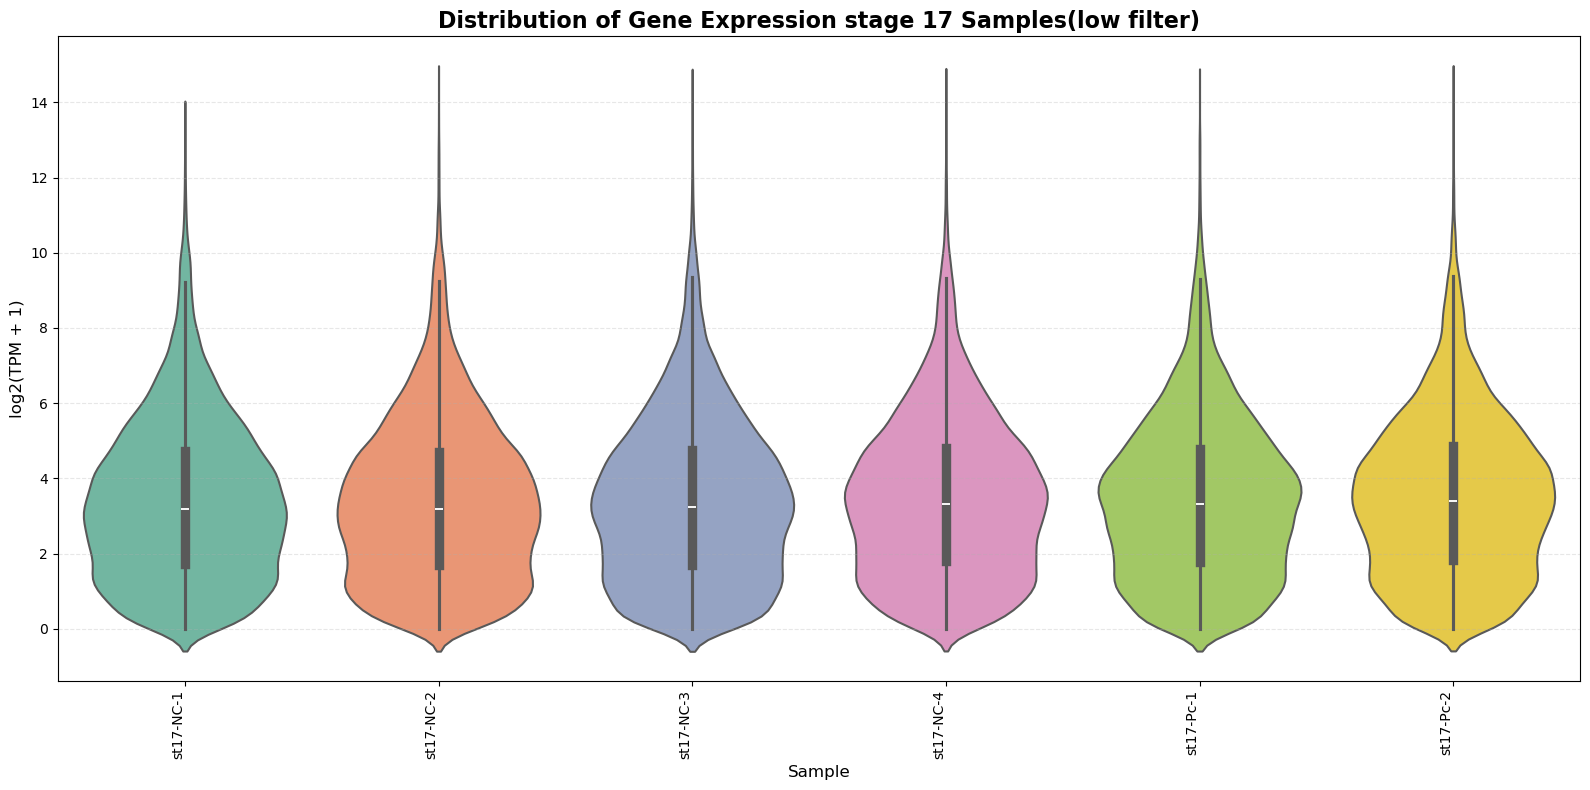

In [23]:
df_orig = rename_sample_columns(input_file='./DEG/merged_tpm_data_17.csv')
df_filtered = filter_genes_low(df_orig)
df_filtered = np.log2(df_filtered + 1)

violin_plot(df_filtered, title='Distribution of Gene Expression stage 17 Samples(low filter)', filename='violin_plot_17_samples_lowfilter.png')
#df_log = np.log2(df_filtered + 1)

/tmp/ipykernel_12897/1380775524.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = df_filtered[gene_vars > var_threshold]
/tmp/ipykernel_12897/867369895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Sample', y= 'Expression',


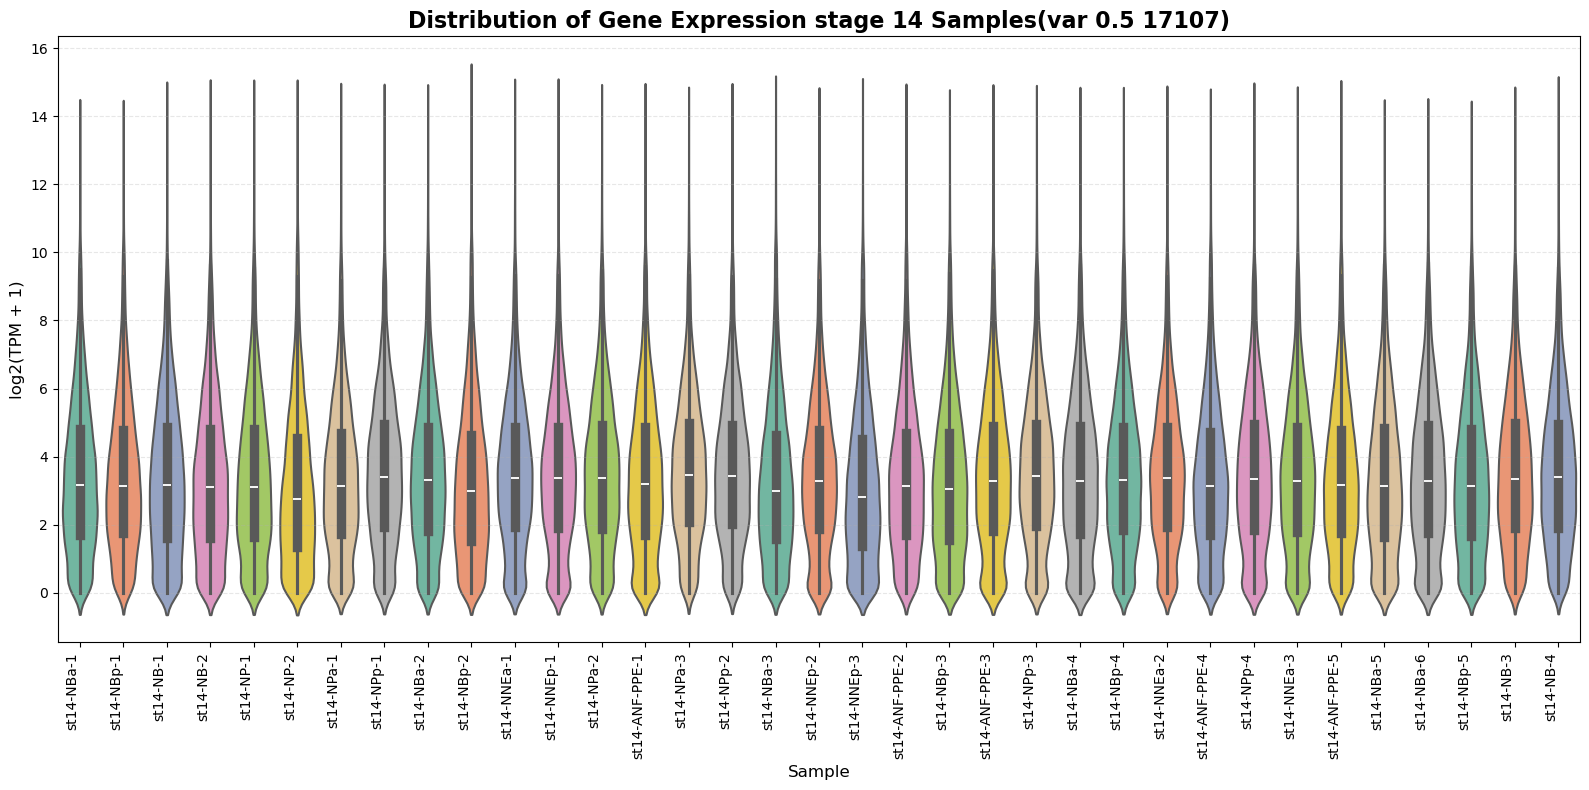

17107

In [10]:
df_filtered_var = filter_genes_var(df_orig, 0.5)
df_filtered_var = np.log2(df_filtered_var+ 1)
violin_plot(df_filtered_var, title='Distribution of Gene Expression stage 14 Samples(var 0.5 17107)', filename='violin_plot_14_samples_varfilter0.5.png')
len(df_filtered_var)
#df_log = np.log2(df_filtered + 1)


발견된 replicate 그룹 수: 9
  st14-NBa: 6 replicates
  st14-NBp: 5 replicates
  st14-NB: 4 replicates
  st14-NP: 2 replicates
  st14-NPa: 3 replicates

제거할 gene 수: 109
전체 gene 수: 20641
남을 gene 수: 20532

제거된 gene 목록이 'removed_genes.txt'에 저장되었습니다.

=== 필터링 통계 ===
st14-ANF-PPE: 39 genes removed
st14-NB: 12 genes removed
st14-NBa: 14 genes removed
st14-NBp: 27 genes removed
st14-NNEa: 10 genes removed
st14-NNEp: 2 genes removed
st14-NPa: 33 genes removed
st14-NPp: 7 genes removed


/tmp/ipykernel_12897/867369895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Sample', y= 'Expression',


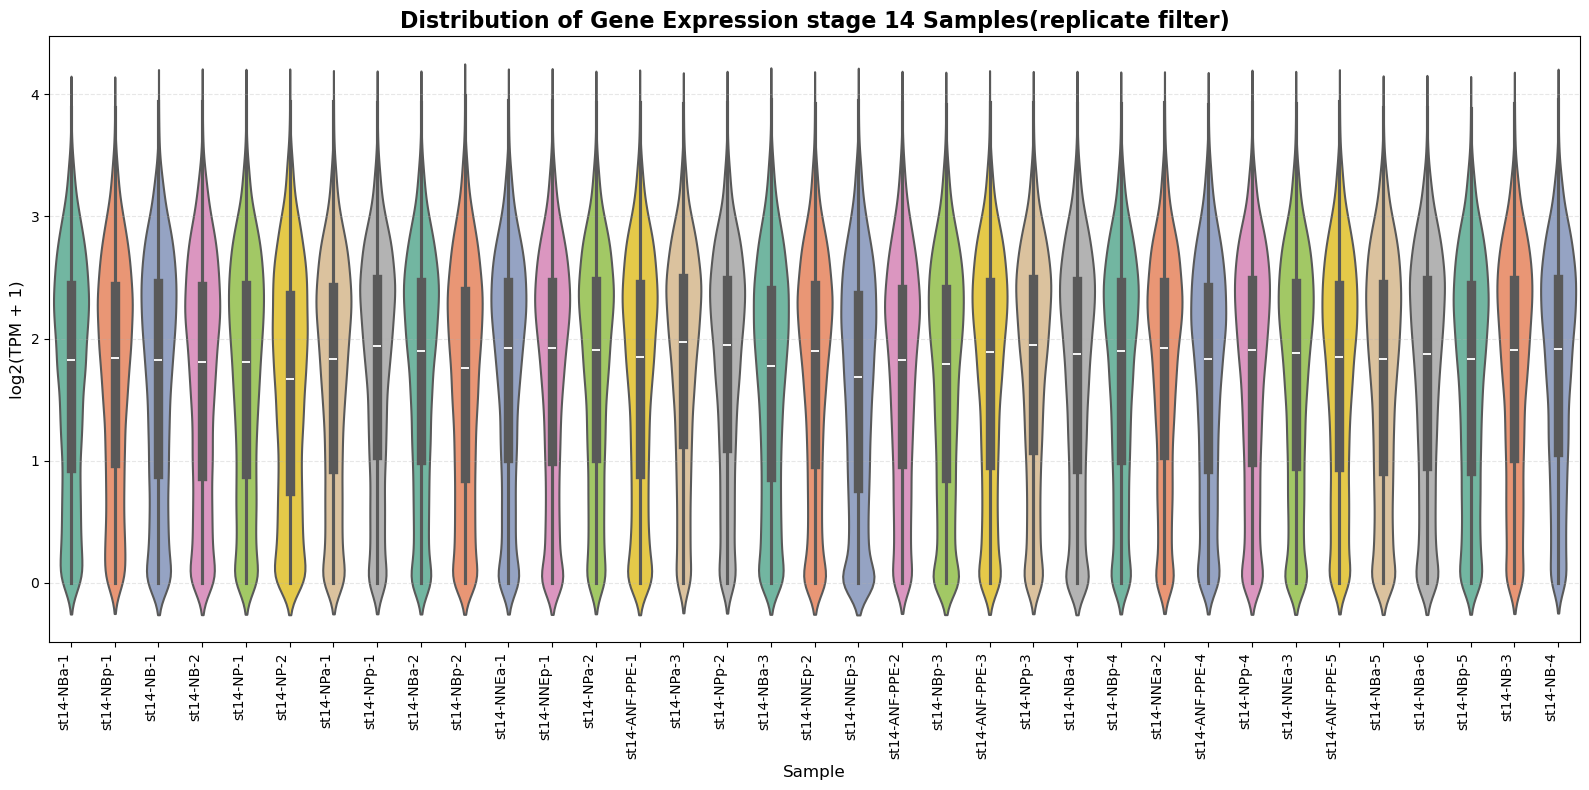

20532

In [11]:
df_filtered_rep = filter_genes_by_replicate(df_filtered)
df_filtered_rep = np.log2(df_filtered_rep + 1)
violin_plot(df_filtered_rep, title='Distribution of Gene Expression stage 14 Samples(replicate filter)', filename='violin_plot_14_samples_repfilter.png')
len(df_filtered_rep)
#df_log = np.log2(df_filtered + 1)

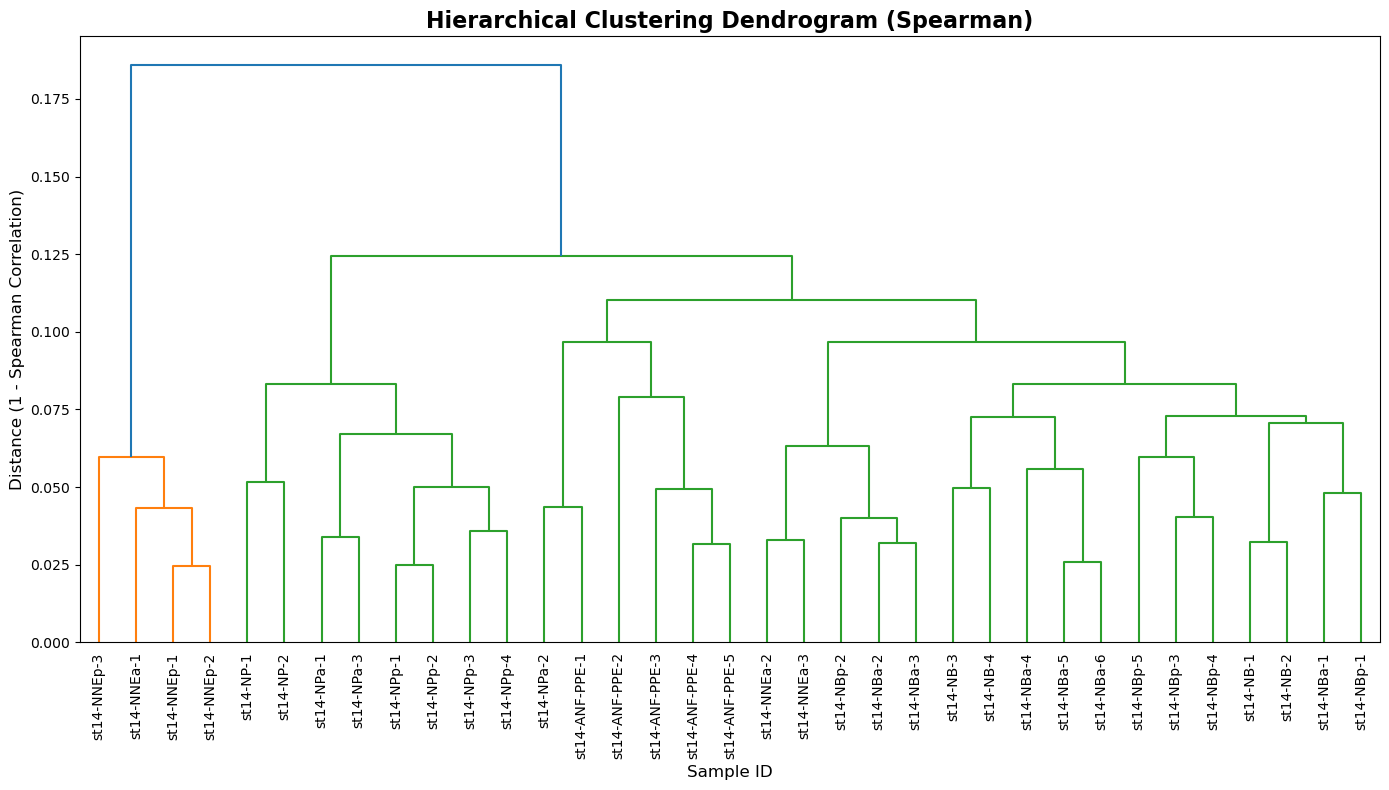

In [12]:
clustering = h_clustering_spearman(df_filtered, title='Hierarchical Clustering Dendrogram (Spearman)', 
                          filename='hclust_spearman_stg14_var.png')

In [13]:
def extract_replicates_by_sample(df, sample_names):
    """
    특정 샘플 이름(stage-tissue)의 replicate들만 추출
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 expression 데이터프레임
    sample_names : list of str
        추출할 샘플 이름 리스트 (예: ['st12-NPp', 'st12-NBp', 'st12-NBl'])
    
    Returns:
    --------
    pandas.DataFrame
        필터링된 데이터프레임 (해당 샘플들의 모든 replicate 포함)
    """
    
    # 모든 컬럼명
    all_columns = df.columns.tolist()
    
    # 선택할 컬럼 리스트
    selected_columns = []
    
    for col in all_columns:
        # 컬럼명에서 마지막 하이픈 앞까지가 샘플 이름 (stage-tissue)
        sample_name = col.rsplit('-', 1)[0]
        
        if sample_name in sample_names:
            selected_columns.append(col)
    
    print(f"\n=== Replicate 추출 결과 ===")
    print(f"요청한 샘플: {sample_names}")
    print(f"추출된 replicate 수: {len(selected_columns)}")
    
    # 샘플별로 replicate 수 출력
    replicate_counts = {}
    for col in selected_columns:
        sample_name = col.rsplit('-', 1)[0]
        replicate_counts[sample_name] = replicate_counts.get(sample_name, 0) + 1
    
    for sample, count in sorted(replicate_counts.items()):
        print(f"  {sample}: {count} replicates")
    
    print(f"추출된 컬럼: {selected_columns}")
    
    # 선택된 컬럼만 반환
    return df[selected_columns]

def cluster_samples_with_replicates(df, sample_names, output_prefix='sample_cluster'):
    """
    특정 샘플들의 replicate을 이용하여 clustering 수행
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 expression 데이터프레임
    sample_names : list of str
        클러스터링할 샘플 이름 리스트 (예: ['st12-NPp', 'st12-NBp'])
    output_prefix : str
        출력 파일명 prefix
    """
    
    print(f"\n{'='*60}")
    print(f"Processing samples: {', '.join(sample_names)}")
    print(f"{'='*60}")
    
    # 해당 샘플들의 replicate 추출
    df_replicates = extract_replicates_by_sample(df, sample_names)
    
    if len(df_replicates.columns) == 0:
        print(f"⚠️  경고: 해당하는 replicate가 없습니다.")
        return None
    
    # Clustering 수행
    title = f'Hierarchical Clustering: {", ".join(sample_names)}'
    filename = f'{output_prefix}.png'
    
    df_filtered = h_clustering_spearman(df_replicates, title=title, filename=filename)
    
    return df_filtered


def cluster_multiple_sample_groups(df, sample_groups, output_prefix='group_cluster'):
    """
    여러 샘플 그룹에 대해 각각 clustering 수행
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 expression 데이터프레임
    sample_groups : dict
        {그룹명: [샘플 이름 리스트]} 형태
        예: {
            'Neural': ['st12-NPp', 'st12-NBp', 'st12-NBl'],
            'Stage12_all': ['st12-NPp', 'st12-NBp', 'st12-NBl', 'st12-NNE']
        }
    output_prefix : str
        출력 파일명 prefix
    """
    
    results = {}
    
    for group_name, sample_names in sample_groups.items():
        print(f"\n{'='*60}")
        print(f"Processing group: {group_name}")
        print(f"{'='*60}")
        
        # 해당 샘플들의 replicate 추출
        df_replicates = extract_replicates_by_sample(df, sample_names)
        
        if len(df_replicates.columns) == 0:
            print(f"⚠️  경고: {group_name}에 해당하는 replicate가 없습니다.")
            continue
        
        # Clustering 수행
        title = f'Hierarchical Clustering: {group_name}'
        filename = f'{output_prefix}_{group_name}.png'
        
        df_filtered = h_clustering_spearman(df_replicates, title=title, filename=filename)
        results[group_name] = df_filtered
    
    return results


Processing samples: st14-NB, st14-NBa, st14-NBp

=== Replicate 추출 결과 ===
요청한 샘플: ['st14-NB', 'st14-NBa', 'st14-NBp']
추출된 replicate 수: 15
  st14-NB: 4 replicates
  st14-NBa: 6 replicates
  st14-NBp: 5 replicates
추출된 컬럼: ['st14-NBa-1', 'st14-NBp-1', 'st14-NB-1', 'st14-NB-2', 'st14-NBa-2', 'st14-NBp-2', 'st14-NBa-3', 'st14-NBp-3', 'st14-NBa-4', 'st14-NBp-4', 'st14-NBa-5', 'st14-NBa-6', 'st14-NBp-5', 'st14-NB-3', 'st14-NB-4']


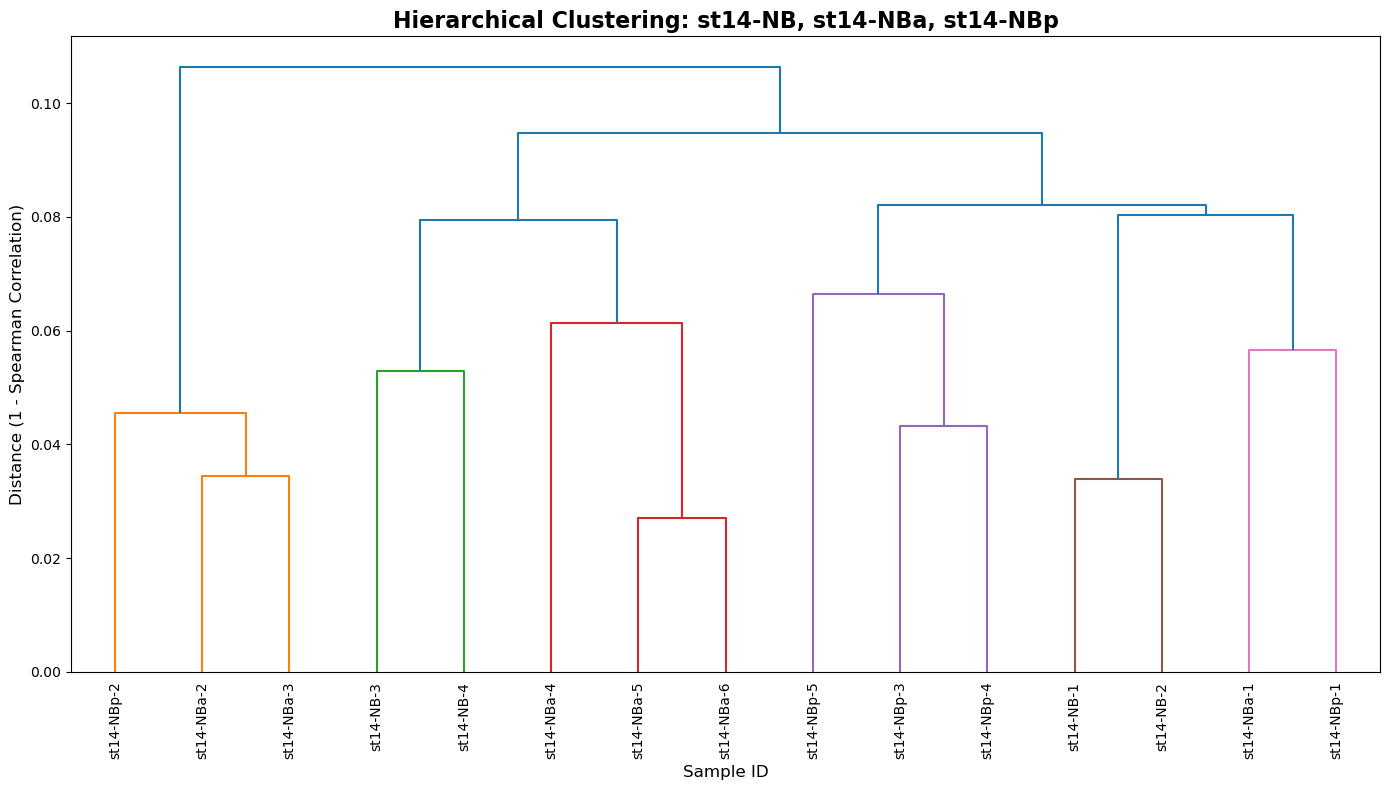

In [14]:
sample_names = ['st14-NB', 'st14-NBa', 'st14-NBp']
df_result = cluster_samples_with_replicates(df_filtered_var, sample_names, 
                                            output_prefix='neural_replicates')


Processing samples: st14-NP, st14-NPa, st14-NPp

=== Replicate 추출 결과 ===
요청한 샘플: ['st14-NP', 'st14-NPa', 'st14-NPp']
추출된 replicate 수: 9
  st14-NP: 2 replicates
  st14-NPa: 3 replicates
  st14-NPp: 4 replicates
추출된 컬럼: ['st14-NP-1', 'st14-NP-2', 'st14-NPa-1', 'st14-NPp-1', 'st14-NPa-2', 'st14-NPa-3', 'st14-NPp-2', 'st14-NPp-3', 'st14-NPp-4']


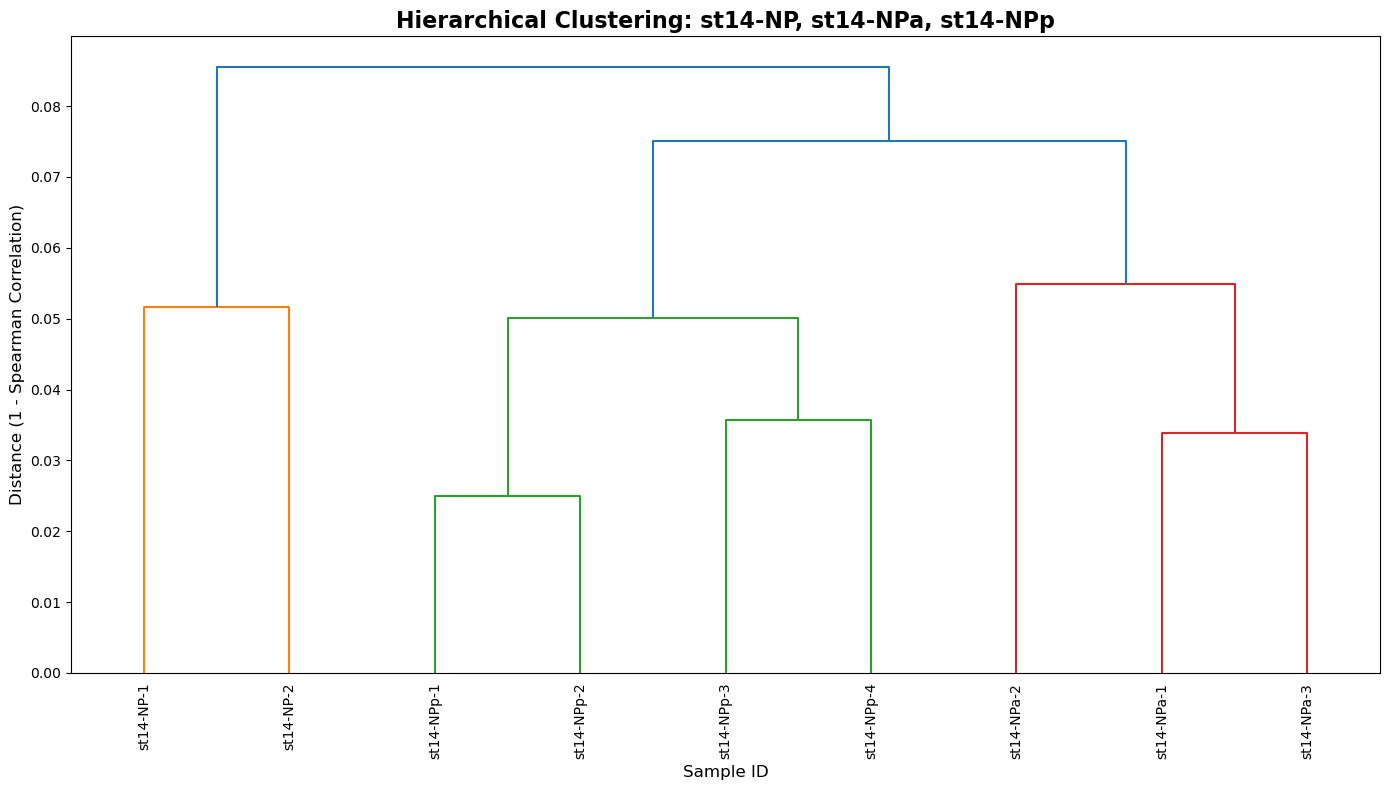

In [15]:
sample_names = ['st14-NP', 'st14-NPa', 'st14-NPp']
df_result = cluster_samples_with_replicates(df_filtered, sample_names, 
                                            output_prefix='neuralplatdf_cleane_replicates')


Processing samples: st14-NP, st14-NPa, st14-NPp, st14-NB, st14-NBa, st14-NBp

=== Replicate 추출 결과 ===
요청한 샘플: ['st14-NP', 'st14-NPa', 'st14-NPp', 'st14-NB', 'st14-NBa', 'st14-NBp']
추출된 replicate 수: 24
  st14-NB: 4 replicates
  st14-NBa: 6 replicates
  st14-NBp: 5 replicates
  st14-NP: 2 replicates
  st14-NPa: 3 replicates
  st14-NPp: 4 replicates
추출된 컬럼: ['st14-NBa-1', 'st14-NBp-1', 'st14-NB-1', 'st14-NB-2', 'st14-NP-1', 'st14-NP-2', 'st14-NPa-1', 'st14-NPp-1', 'st14-NBa-2', 'st14-NBp-2', 'st14-NPa-2', 'st14-NPa-3', 'st14-NPp-2', 'st14-NBa-3', 'st14-NBp-3', 'st14-NPp-3', 'st14-NBa-4', 'st14-NBp-4', 'st14-NPp-4', 'st14-NBa-5', 'st14-NBa-6', 'st14-NBp-5', 'st14-NB-3', 'st14-NB-4']


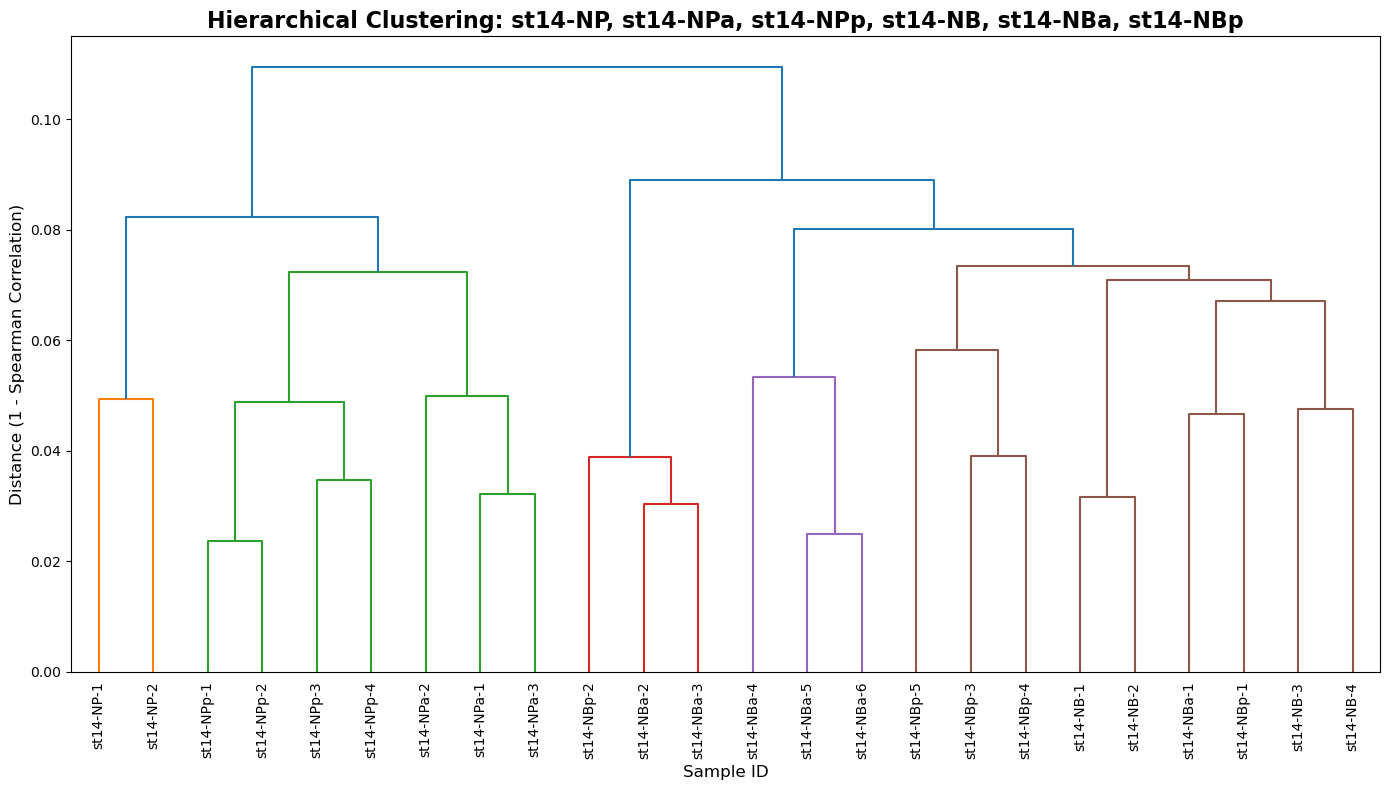

In [16]:
sample_names = ['st14-NP', 'st14-NPa', 'st14-NPp', 'st14-NB', 'st14-NBa', 'st14-NBp']
df_result = cluster_samples_with_replicates(df_filtered_rep, sample_names, 
                                            output_prefix='neural_PB_replicates')


Processing samples: st14-ANF-PPE, st14-NP, st14-NPa, st14-NPp

=== Replicate 추출 결과 ===
요청한 샘플: ['st14-ANF-PPE', 'st14-NP', 'st14-NPa', 'st14-NPp']
추출된 replicate 수: 14
  st14-ANF-PPE: 5 replicates
  st14-NP: 2 replicates
  st14-NPa: 3 replicates
  st14-NPp: 4 replicates
추출된 컬럼: ['st14-NP-1', 'st14-NP-2', 'st14-NPa-1', 'st14-NPp-1', 'st14-NPa-2', 'st14-ANF-PPE-1', 'st14-NPa-3', 'st14-NPp-2', 'st14-ANF-PPE-2', 'st14-ANF-PPE-3', 'st14-NPp-3', 'st14-ANF-PPE-4', 'st14-NPp-4', 'st14-ANF-PPE-5']


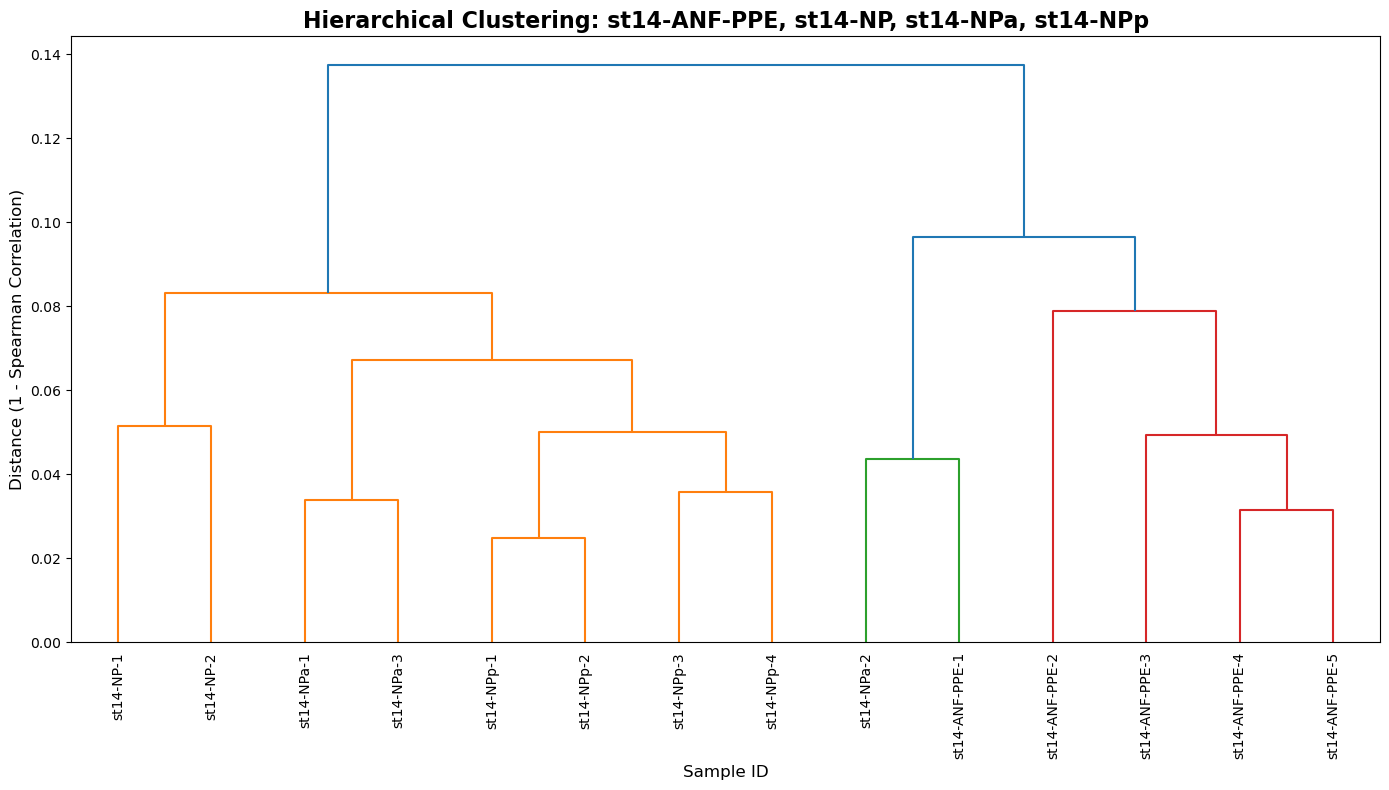

In [17]:
sample_names = ['st14-ANF-PPE','st14-NP', 'st14-NPa', 'st14-NPp']
df_result = cluster_samples_with_replicates(df_filtered, sample_names, 
                                            output_prefix='ANF_NP_replicates')

제외할 샘플 수: 5
제외할 샘플 목록: ['st14-NBp-1', 'st14-NBp-2', 'st14-NBa-1', 'st14-NBa-2', 'st14-NBa-3']

Processing samples: st14-NB, st14-NBa, st14-NBp

=== Replicate 추출 결과 ===
요청한 샘플: ['st14-NB', 'st14-NBa', 'st14-NBp']
추출된 replicate 수: 10
  st14-NB: 4 replicates
  st14-NBa: 3 replicates
  st14-NBp: 3 replicates
추출된 컬럼: ['st14-NB-1', 'st14-NB-2', 'st14-NBp-3', 'st14-NBa-4', 'st14-NBp-4', 'st14-NBa-5', 'st14-NBa-6', 'st14-NBp-5', 'st14-NB-3', 'st14-NB-4']


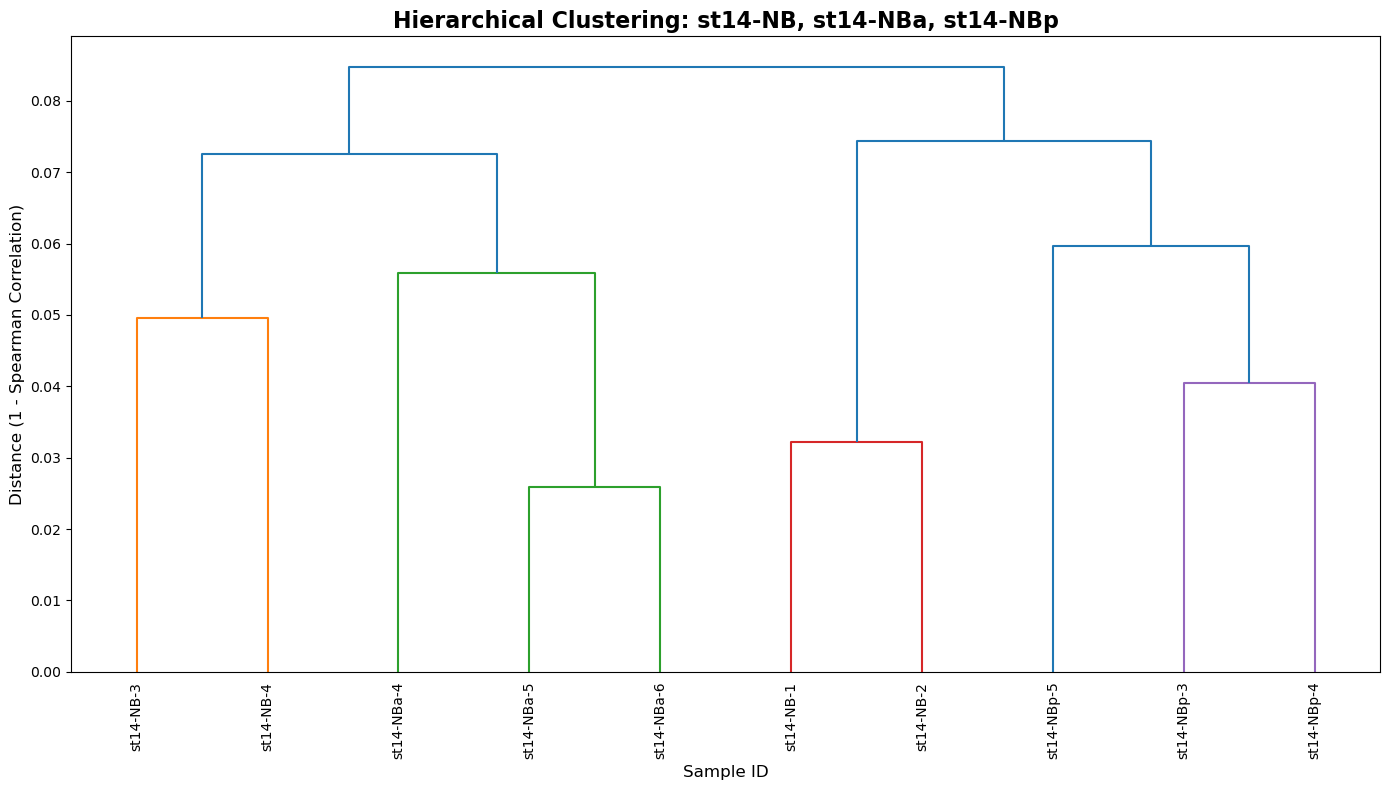

In [18]:
df_filtered_excluded = exclude_samples(df_filtered, exclude_patterns=['NBp-1', 'NBp-2','NBa-1','NBa-2','NBa-3'])
sample_names = ['st14-NB', 'st14-NBa', 'st14-NBp']
df_result = cluster_samples_with_replicates(df_filtered_excluded, sample_names, 
                                            output_prefix='neural_replicates')

In [27]:
## Scatter plot for two samples
def scatter_plot_two_samples(df, sample_x, sample_y, title='Scatter Plot of Two Samples', 
                             xlabel='Sample X', ylabel='Sample Y', 
                             filename='scatter_plot_two_samples.png'):
    """
    두 샘플 간의 scatter plot 생성
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 log(expression) 데이터프레임
    sample_x : str
        x축에 사용할 샘플 이름
    sample_y : str
        y축에 사용할 샘플 이름
    title : str
        그래프 제목
    xlabel : str
        x축 레이블
    ylabel : str
        y축 레이블
    filename : str
        저장할 파일명
    """
    

    if sample_x not in df.columns or sample_y not in df.columns:
        print(f"⚠️  경고: 지정한 샘플이 데이터프레임에 없습니다.")
        return

    remove_low = df[(df[sample_x] > 1) | (df[sample_y] > 1)]

    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=remove_low, x=sample_x, y=sample_y, alpha=0.5)
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    
    # 대각선 추가
    max_val = max(df[sample_x].max(), df[sample_y].max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
    
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

def calculate_correlations(df, sample1, sample2):
    """
    두 샘플 간 Pearson과 Spearman correlation 계산
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 expression 데이터프레임
    sample1 : str
        첫 번째 샘플 컬럼명
    sample2 : str
        두 번째 샘플 컬럼명
    
    Returns:
    --------
    dict
        {'pearson_r': float, 'pearson_p': float, 
         'spearman_r': float, 'spearman_p': float}
    """
    
    # 두 샘플의 데이터 추출
    data1 = df[sample1]
    data2 = df[sample2]
    
    # NaN이나 무한대 제거
    mask = ~(np.isnan(data1) | np.isnan(data2) | 
             np.isinf(data1) | np.isinf(data2))
    
    clean_data1 = data1[mask]
    clean_data2 = data2[mask]
    
    # Pearson correlation 계산
    pearson_r, pearson_p = pearsonr(clean_data1, clean_data2)
    
    # Spearman correlation 계산
    spearman_r, spearman_p = spearmanr(clean_data1, clean_data2)
    
    print(f"\n=== Correlation between {sample1} and {sample2} ===")
    print(f"Valid data points: {len(clean_data1)} genes")
    print(f"\nPearson correlation:")
    print(f"  r = {pearson_r:.4f}")
    print(f"  p-value = {pearson_p:.4e}")
    print(f"\nSpearman correlation:")
    print(f"  r = {spearman_r:.4f}")
    print(f"  p-value = {spearman_p:.4e}")
    
    return {
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p,
        'n_genes': len(clean_data1)
    }

    

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


def scatter_plot_two_samples(df, sample_x, sample_y, title, xlabel, ylabel, filename):
    """
    두 샘플 간 scatter plot 생성 (특정 유전자 강조 및 correlation 표시)
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 expression 데이터프레임
    sample_x : str
        x축 샘플명
    sample_y : str
        y축 샘플명
    title : str
        그래프 제목
    xlabel : str
        x축 라벨
    ylabel : str
        y축 라벨
    filename : str
        저장할 파일명
    """
    
    # 특정 유전자 정의
    highlight_genes = {
        "399406": "HRAS",
        "100505423": "KRAS.L",
        "108712520": "KRAS.S",
        "399446": "NRAS"
    }
    remove_low = df[(df[sample_x] > 1) & (df[sample_y] > 1)]
    # 데이터 추출
    data_x = remove_low[sample_x]
    data_y = remove_low[sample_y]
    
    # NaN이나 무한대 제거
    mask = ~(np.isnan(data_x) | np.isnan(data_y) | 
             np.isinf(data_x) | np.isinf(data_y))
    
    clean_data_x = data_x[mask]
    clean_data_y = data_y[mask]
    clean_index = remove_low.index[mask]
    
    # Correlation 계산
    pearson_r, pearson_p = pearsonr(clean_data_x, clean_data_y)
    spearman_r, spearman_p = spearmanr(clean_data_x, clean_data_y)
    
    # Plot 생성
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # 일반 점들 (회색)
    ax.scatter(clean_data_x, clean_data_y, alpha=0.3, s=20, color='gray', label='Other genes')
    
    # 특정 유전자 강조
    for gene_id, gene_name in highlight_genes.items():
        # GeneID 형식 처리 (GeneID: 접두사가 있을 수 있음)
        gene_id_variants = [gene_id, f"GeneID:{gene_id}"]
        
        for variant in gene_id_variants:
            if variant in clean_index:
                x_val = clean_data_x[variant]
                y_val = clean_data_y[variant]
                ax.scatter(x_val, y_val, s=200, alpha=0.8, 
                          marker='*', edgecolors='black', linewidth=2,
                          label=gene_name, zorder=5)
                
                # 유전자 이름 라벨 추가
                ax.annotate(gene_name, 
                           (x_val, y_val),
                           xytext=(10, 10), 
                           textcoords='offset points',
                           fontsize=10, 
                           fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.5', 
                                   facecolor='yellow', 
                                   alpha=0.7),
                           arrowprops=dict(arrowstyle='->', 
                                         connectionstyle='arc3,rad=0',
                                         lw=1.5))
                break
    
    # 대각선 추가
    min_val = min(clean_data_x.min(), clean_data_y.min())
    max_val = max(clean_data_x.max(), clean_data_y.max())
    ax.plot([min_val, max_val], [min_val, max_val], 
           'r--', alpha=0.5, linewidth=2, label='y=x')
    
    # Correlation 텍스트 박스 추가 (왼쪽 위)
    textstr = f'Pearson r = {pearson_r:.4f}\n(p = {pearson_p:.2e})\n\nSpearman ρ = {spearman_r:.4f}\n(p = {spearman_p:.2e})\n\nn = {len(clean_data_x)} genes'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, 
           fontsize=11, verticalalignment='top', bbox=props)
    
    # 축 라벨 및 제목
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # 로그 스케일 적용
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # 그리드 추가
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 범례
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"Saved: {filename}")
    print(f"  Pearson r = {pearson_r:.4f}, Spearman ρ = {spearman_r:.4f}")
    
# Correlation 통계 반환
    return {
        'sample_x': sample_x,
        'sample_y': sample_y,
# 예시 1: 전체 워크플로우 실행
# samples_to_exclude = ['st12-NPp-1', 'st12-NBp-3']  # 제외할 샘플
# gene_list = ["399406", "100505423", "108712520", "399446"]  # 분석할 유전자
# 
# df_filtered, df_averaged, groups = complete_workflow(
#     df, 
#     samples_to_exclude, 
#     gene_list,
#     output_prefix='my_analysis'
# )

# 예시 2: 단계별 실행
# # Step 1: 샘플 제외
# samples_to_exclude = ['st12-NPp-1', 'st12-NBp-3']
# df_filtered = exclude_samples(df, samples_to_exclude)
# 
# # Step 2: 개별 샘플 heatmap
# gene_list = ["399406", "100505423", "108712520", "399446"]
# plot_expression_heatmap(df_filtered, gene_list, 
#                        output_file='individual_heatmap.png')
# 
# # Step 3: Replicate 평균
# df_averaged, groups = group_replicates(df_filtered)
# 
# # Step 4: 평균 데이터 heatmap
# plot_expression_heatmap(df_averaged, gene_list,
#                        output_file='averaged_heatmap.png')
# 
# # Step 5: 특정 두 그룹 scatter plot
# plot_grouped_scatter(df_averaged, 'st12-NPp', 'st12-NBp',
#                     gene_list=gene_list,
#                     output_file='scatter_NPp_vs_NBp.png')
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p,
        'n_genes': len(clean_data_x)
    }


def plotting_scatter_for_df(df, output_prefix='scatter_plot', save_correlations=True):
    """
    df의 모든 column 쌍에 대해 scatter plot 생성 및 저장
    
    Parameters:
    -----------
    df : pandas.DataFrame
        인덱스가 GeneID이고 컬럼이 샘플인 expression 데이터프레임
    output_prefix : str
        출력 파일명 prefix
    """
    
    columns = df.columns.tolist()
    num_columns = len(columns)
    total_plots = (num_columns * (num_columns - 1)) // 2
    
    print(f"\n{'='*60}")
    print(f"Generating scatter plots for all sample pairs")
    print(f"Total samples: {num_columns}")
    print(f"Total plots to generate: {total_plots}")
    print(f"{'='*60}\n")
    
    plot_count = 0
    
    
    correlation_results = []
    
    for i in range(num_columns):
        for j in range(i + 1, num_columns):
            sample_x = columns[i]
            sample_y = columns[j]
            
            plot_count += 1
            
            # Scatter plot 생성
            title = f'Scatter Plot: {sample_x} vs {sample_y}'
            xlabel = sample_x
            ylabel = sample_y
            filename = f'{output_prefix}_{sample_x}_vs_{sample_y}.png'
            
            print(f"[{plot_count}/{total_plots}] Plotting {sample_x} vs {sample_y}...")
            
            corr_stats = scatter_plot_two_samples(df, sample_x, sample_y, 
                                                  title, xlabel, ylabel, filename)
            
            # Correlation 결과 저장
            correlation_results.append(corr_stats)
    
    print(f"\n{'='*60}")
    print(f"All {total_plots} scatter plots have been generated!")
    print(f"{'='*60}\n")
    
    # Correlation 결과를 DataFrame으로 변환
    corr_df = pd.DataFrame(correlation_results)
    
    # CSV 파일로 저장
    if save_correlations:
        corr_filename = f'{output_prefix}_correlations.csv'
        corr_df.to_csv(corr_filename, index=False)
        print(f"Correlation results saved to: {corr_filename}\n")
    
    return corr_df


In [48]:
df_orig = rename_sample_columns(input_file='./DEG/merged_tpm_data_14.csv')
df_filtered = filter_genes_low(df_orig)

Original data shape: (70682, 36)
Filtered data shape: (34475, 36)
Removed 36207 rows containing 'STRG'
코드 매핑이 'code_mapping.txt'에 저장되었습니다.

변경된 컬럼명 예시:
['GeneID', 'st14-NBa-1', 'st14-NBp-1', 'st14-NB-1', 'st14-NB-2', 'st14-NP-1', 'st14-NP-2', 'st14-NPa-1', 'st14-NPp-1', 'st14-NBa-2']


In [49]:
plotting_scatter_for_df(df_filtered, output_prefix='DEG/st14/st14_scatter')
# selected_samples = ['st12-NPp-1', 'st12-NPp-2', 'st12-NBp-1', 'st12-NBp-2']
# df_subset = df_filtered_rep[selected_samples]
# plotting_scatter_for_df(df_subset, output_prefix='selected_scatter')


Generating scatter plots for all sample pairs
Total samples: 35
Total plots to generate: 595

[1/595] Plotting st14-NBa-1 vs st14-NBp-1...
Saved: DEG/st14/st14_scatter_st14-NBa-1_vs_st14-NBp-1.png
  Pearson r = 0.9853, Spearman ρ = 0.9431
[2/595] Plotting st14-NBa-1 vs st14-NB-1...
Saved: DEG/st14/st14_scatter_st14-NBa-1_vs_st14-NB-1.png
  Pearson r = 0.9705, Spearman ρ = 0.8999
[3/595] Plotting st14-NBa-1 vs st14-NB-2...
Saved: DEG/st14/st14_scatter_st14-NBa-1_vs_st14-NB-2.png
  Pearson r = 0.9650, Spearman ρ = 0.9029
[4/595] Plotting st14-NBa-1 vs st14-NP-1...
Saved: DEG/st14/st14_scatter_st14-NBa-1_vs_st14-NP-1.png
  Pearson r = 0.9689, Spearman ρ = 0.8918
[5/595] Plotting st14-NBa-1 vs st14-NP-2...
Saved: DEG/st14/st14_scatter_st14-NBa-1_vs_st14-NP-2.png
  Pearson r = 0.9489, Spearman ρ = 0.8630
[6/595] Plotting st14-NBa-1 vs st14-NPa-1...
Saved: DEG/st14/st14_scatter_st14-NBa-1_vs_st14-NPa-1.png
  Pearson r = 0.9325, Spearman ρ = 0.9190
[7/595] Plotting st14-NBa-1 vs st14-NPp-1..

,sample_x,sample_y,pearson_r,pearson_p,spearman_r,spearman_p,n_genes
0,st14-NBa-1,st14-NBp-1,0.985338,0.0,0.943093,0.0,14456
1,st14-NBa-1,st14-NB-1,0.970468,0.0,0.899879,0.0,13869
2,st14-NBa-1,st14-NB-2,0.965015,0.0,0.902855,0.0,13856
3,st14-NBa-1,st14-NP-1,0.968856,0.0,0.891751,0.0,13776
4,st14-NBa-1,st14-NP-2,0.948854,0.0,0.862979,0.0,13240
...,...,...,...,...,...,...,...
590,st14-NBa-6,st14-NB-3,0.969277,0.0,0.915440,0.0,14259
591,st14-NBa-6,st14-NB-4,0.961163,0.0,0.923461,0.0,14395
592,st14-NBp-5,st14-NB-3,0.975588,0.0,0.906263,0.0,14102
593,st14-NBp-5,st14-NB-4,0.960996,0.0,0.909174,0.0,14186
